# Q1 [4 marks]
## Objective

To implement **LDA** from scratch and analyze how class-specific covariance structures influence classification performance  

Part 1: The Homoscedastic Case (Same Covariance)

In this scenario, we satisfy the core assumption of LDA: all classes share the same shape and orientation in space.  

Task 1: Data Generation

Generate a dataset in R10 with 3 classes.

    Means: μ1​,μ2​,μ3​ should be distinct.

    Covariance: Use a single Σ for all classes.


In [1]:
import numpy as np
from tqdm import tqdm
from tabulate import tabulate
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim


In [2]:
#constants
random_state = 2402
np.random.seed(random_state)
epsilon = 1e-6

n_classes = 3
n_dimensions = 10
projection_dim = 2
n_samples_per_class = 500

u1 = np.zeros(n_dimensions)
u2 = np.ones(n_dimensions)*2
u3 = np.ones(n_dimensions)*(-2)

I_dash = np.eye(n_dimensions)*epsilon


In [3]:
# Implement Part 1
# homoscedastic data generation

sm = np.random.rand(n_dimensions, n_dimensions)
Sigma_matrix = sm @ sm.T + I_dash # To ensure it's positive definite

X_hm = []
y_hm = []

for idx, u in enumerate([u1, u2, u3]):
    samples = np.random.multivariate_normal(u, Sigma_matrix, n_samples_per_class)
    X_hm.append(samples)
    y_hm.append(np.full(n_samples_per_class, idx))

X_hm = np.vstack(X_hm)
y_hm = np.hstack(y_hm)

print("Shape of X homoscedastic:", X_hm.shape)
print("Shape of y homoscedastic:", y_hm.shape)

Shape of X homoscedastic: (1500, 10)
Shape of y homoscedastic: (1500,)


Task 2: Implementation & Visualization

    Implement the SW​ and SB​ calculations.

    Project the 10D data into 2D.

    Plot: Use a scatter plot to visualize the classes in the new 2D space.

In [4]:
# Implement Task 2
# LDA function
def lda_projection(X,y,n_components=2):
    '''
    Sw(within class scatter) = ∑(Nc-1)* ∑(xi−mc​)(xi−mc​)T
    Sb(between class scatter) = ∑Nc*(mc-u)(mc-u)T
    W = eigenvectors of Sw−1​Sb​
    returns: prjected data on given components and projection matrix 
    '''
    
    class_labels = np.unique(y)
    n_classes = len(class_labels)
    n_features = X.shape[1]

    u = np.mean(X, axis=0)
    class_u = np.array([np.mean(X[y == i], axis=0) for i in class_labels])

    Sw = np.zeros((n_features, n_features))
    Sb = np.zeros((n_features, n_features))

    for idx,c in enumerate(class_labels):
        X_c = X[y == c]  
        mean_c = class_u[idx] 
        mean_diff = (mean_c - u).reshape(-1, 1) 

        Sw += np.cov(X_c, rowvar=False) * (X_c.shape[0] - 1) 
        Sb += X_c.shape[0] * (mean_diff @ mean_diff.T)

    Sw += I_dash  # To ensure Sw is invertible 

    mat = np.linalg.inv(Sw) @ Sb
    eigvals, eigvecs = np.linalg.eig(mat)
    eigvals, eigvecs = eigvals.real, eigvecs.real 
    sorted_indices = np.argsort(eigvals)[::-1]
    W = eigvecs[:, sorted_indices[:n_components]]

    x_projected = X @ W

    return x_projected, W


In [5]:
X_train_hm, X_test_hm, y_train_hm, y_test_hm = train_test_split(X_hm, y_hm, test_size=0.3, random_state=random_state)

# Project training data
X_train_projected_hm, W = lda_projection(X_train_hm, y_train_hm, n_components=projection_dim)
print("Shape of projected X:", X_train_projected_hm.shape)
print("Projection matrix W shape:", W.shape)

# Project test data
X_test_projected_hm = X_test_hm @ W
print("Shape of projected X test:", X_test_projected_hm.shape)


Shape of projected X: (1050, 2)
Projection matrix W shape: (10, 2)
Shape of projected X test: (450, 2)


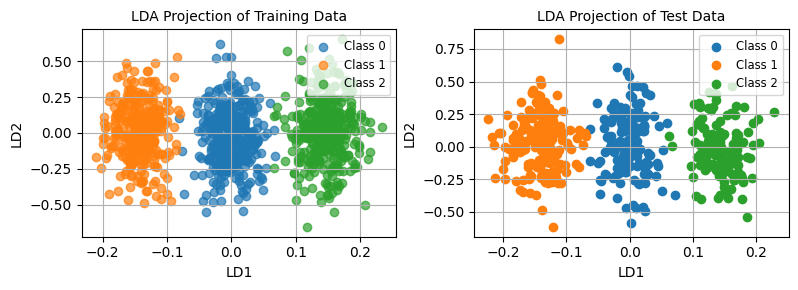

In [6]:
# visulazing data 
# training data homoscedastic case
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
for class_label in np.unique(y_train_hm):
    plt.scatter(X_train_projected_hm[y_train_hm == class_label, 0], X_train_projected_hm[y_train_hm == class_label, 1], label=f'Class {class_label}', alpha=0.7)
plt.title('LDA Projection of Training Data', fontsize=10)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

# test data homoscedastic case
plt.subplot(1, 2, 2)
for class_label in np.unique(y_test_hm):
    plt.scatter(X_test_projected_hm[y_test_hm == class_label, 0], X_test_projected_hm[y_test_hm == class_label, 1], label=f'Class {class_label}')

plt.title('LDA Projection of Test Data', fontsize=10)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

Part 2: The Heteroscedastic Case (Different Covariances)

What happens when classes have different shapes? 

Task 3: Data Generation

Generate a new 10D dataset where each class has a unique covariance matrix (Σ1​,Σ2​,Σ3​).

In [7]:
# Implement Task 
# heteroscedastic data generation

sigma_mat_dict = {}
for i in range(n_classes):
    sm = np.random.rand(n_dimensions, n_dimensions)
    sigma_mat_dict[i] = sm @ sm.T + I_dash # To ensure it's positive definite


X_ht = []
y_ht = []

for idx, u in enumerate([u1, u2, u3]):
    samples = np.random.multivariate_normal(u, sigma_mat_dict[idx], n_samples_per_class)
    X_ht.append(samples)
    y_ht.append(np.full(n_samples_per_class, idx))


X_ht = np.vstack(X_ht)
y_ht = np.hstack(y_ht)

print("Shape of X heteroscedastic:", X_ht.shape)
print("Shape of y heteroscedastic:", y_ht.shape)

Shape of X heteroscedastic: (1500, 10)
Shape of y heteroscedastic: (1500,)


Task 4: Comparison

    LDA Pipeline: Apply your scratch LDA to this new data, project to 2D, and train a classifier.

    QDA Implementation: Use sklearn library to classify the data.

In [8]:
# Implement Task 4
# projecting and visualizing heteroscedastic data

X_train_ht, X_test_ht, y_train_ht, y_test_ht = train_test_split(X_ht, y_ht, test_size=0.3, random_state=random_state)
x_train_projected_ht, W_ht = lda_projection(X_train_ht, y_train_ht, n_components=2)
print("Shape of projected X heteroscedastic:", x_train_projected_ht.shape)
print("Projection matrix W heteroscedastic shape:", W_ht.shape)

X_test_projected_ht = X_test_ht @ W_ht
print("Shape of projected X test heteroscedastic:", X_test_projected_ht.shape)

Shape of projected X heteroscedastic: (1050, 2)
Projection matrix W heteroscedastic shape: (10, 2)
Shape of projected X test heteroscedastic: (450, 2)


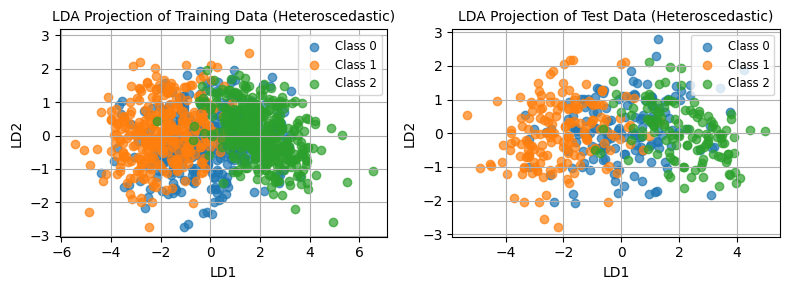

In [9]:
plt.figure(figsize=(8, 3))

# training data heteroscedastic case
plt.subplot(1, 2, 1)
for class_label in np.unique(y_train_ht):
    plt.scatter(x_train_projected_ht[y_train_ht == class_label, 0], x_train_projected_ht[y_train_ht == class_label, 1], label=f'Class {class_label}', alpha=0.7)

plt.title('LDA Projection of Training Data (Heteroscedastic)', fontsize=10)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

# test data heteroscedastic case
plt.subplot(1, 2, 2)
for class_label in np.unique(y_test_ht):
    plt.scatter(X_test_projected_ht[y_test_ht == class_label, 0], X_test_projected_ht[y_test_ht == class_label, 1], label=f'Class {class_label}', alpha=0.7)
plt.title('LDA Projection of Test Data (Heteroscedastic)', fontsize=10)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

Discussion & Analysis

After running your experiments, please provide a brief write-up addressing the following:

    Performance Gap: Compare the accuracy of LDA vs. QDA in Part 2.

    Compare the projections in Part 2 between LDA and QDA. Explain the reasoning behind it.
  

In [10]:
# linear and QDA classifiers comparison
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

knn_classifier = KNeighborsClassifier(n_neighbors=5)
linear_classifier = LogisticRegression()
# Store covariance for QDA to handle heteroscedasticity
qda_classifier = QuadraticDiscriminantAnalysis(store_covariance=True) 

# on projected features 
linear_classifier.fit(X_train_projected_hm, y_train_hm)
knn_classifier.fit(X_train_projected_hm, y_train_hm) 
# on all features 
qda_classifier.fit(X_train_hm, y_train_hm) 

y_pred_linear = linear_classifier.predict(X_test_projected_hm) 
y_pred_knn = knn_classifier.predict(X_test_projected_hm)
y_pred_qda = qda_classifier.predict(X_test_hm)

acc_linear_test = accuracy_score(y_test_hm, y_pred_linear)
acc_knn_test = accuracy_score(y_test_hm, y_pred_knn)
acc_qda_test = accuracy_score(y_test_hm, y_pred_qda)


y_pred_linear = linear_classifier.predict(X_train_projected_hm)
y_pred_knn = knn_classifier.predict(X_train_projected_hm)
y_pred_qda = qda_classifier.predict(X_train_hm)

acc_linear_train = accuracy_score(y_train_hm, y_pred_linear)
acc_knn_train = accuracy_score(y_train_hm, y_pred_knn)
acc_qda_train = accuracy_score(y_train_hm, y_pred_qda)


print(tabulate([['Linear Classifier', acc_linear_train, acc_linear_test],
                ['KNN Classifier', acc_knn_train, acc_knn_test],
                ['QDA Classifier', acc_qda_train, acc_qda_test]],
                 headers=['Classifier', 'Training Accuracy', 'Test Accuracy'], tablefmt='grid'))

+-------------------+---------------------+-----------------+
| Classifier        |   Training Accuracy |   Test Accuracy |
+===================+=====================+=================+
| Linear Classifier |            0.989524 |        0.991111 |
+-------------------+---------------------+-----------------+
| KNN Classifier    |            0.995238 |        0.988889 |
+-------------------+---------------------+-----------------+
| QDA Classifier    |            0.99619  |        0.988889 |
+-------------------+---------------------+-----------------+


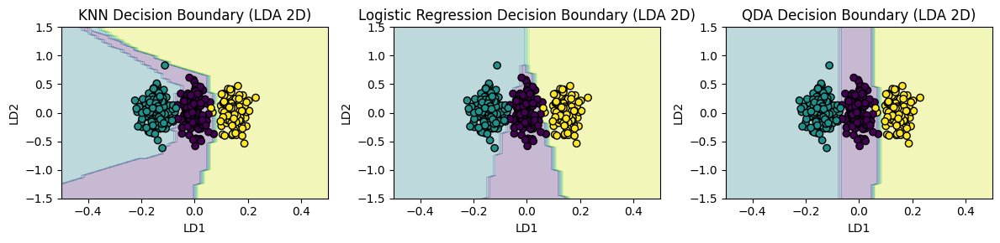

In [11]:
plt.figure(figsize=(12,3))


ax1 = plt.subplot(1,3, 1)
DecisionBoundaryDisplay.from_estimator(
    knn_classifier,
    X_test_projected_hm,
    response_method="predict",
    alpha=0.3,
    ax=ax1
)

ax1.scatter(
    X_test_projected_hm[:, 0],
    X_test_projected_hm[:, 1],
    c=y_test_hm,
    edgecolor='k'
)

ax1.set_xlim(-0.5, 0.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_title("KNN Decision Boundary (LDA 2D)")
ax1.set_xlabel("LD1")
ax1.set_ylabel("LD2")


ax2 = plt.subplot(1, 3, 2)

DecisionBoundaryDisplay.from_estimator(
    linear_classifier,
    X_test_projected_hm,
    response_method="predict",
    alpha=0.3,
    ax=ax2
)

ax2.scatter(
    X_test_projected_hm[:, 0],
    X_test_projected_hm[:, 1],
    c=y_test_hm,
    edgecolor='k'
)

ax2.set_xlim(-0.5, 0.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_title("Logistic Regression Decision Boundary (LDA 2D)")
ax2.set_xlabel("LD1")
ax2.set_ylabel("LD2")


ax3 = plt.subplot(1, 3, 3)
qda_2d = QuadraticDiscriminantAnalysis()
qda_2d.fit(X_train_projected_hm, y_train_hm)


DecisionBoundaryDisplay.from_estimator(
    qda_2d,
    X_test_projected_hm,
    response_method="predict",
    alpha=0.3,
    ax=ax3
)

ax3.scatter(
    X_test_projected_hm[:, 0],
    X_test_projected_hm[:, 1],
    c=y_test_hm,
    edgecolor='k'
)

ax3.set_xlim(-0.5, 0.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_title("QDA Decision Boundary (LDA 2D)")
ax3.set_xlabel("LD1")
ax3.set_ylabel("LD2")

plt.tight_layout()
plt.show()

In [12]:
# linear and QDA classifiers comparison
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

knn_classifier = KNeighborsClassifier(n_neighbors=5)
linear_classifier = LogisticRegression()
# Store covariance for QDA to handle heteroscedasticity
qda_classifier = QuadraticDiscriminantAnalysis(store_covariance=True) 

# on projected features 
linear_classifier.fit(x_train_projected_ht, y_train_ht)
knn_classifier.fit(x_train_projected_ht, y_train_ht) 
# on all features 
qda_classifier.fit(X_train_ht, y_train_ht) 

y_pred_linear = linear_classifier.predict(X_test_projected_ht) 
y_pred_knn = knn_classifier.predict(X_test_projected_ht)
y_pred_qda = qda_classifier.predict(X_test_ht)

acc_linear_test = accuracy_score(y_test_ht, y_pred_linear)
acc_knn_test = accuracy_score(y_test_ht, y_pred_knn)
acc_qda_test = accuracy_score(y_test_ht, y_pred_qda)


y_pred_linear = linear_classifier.predict(x_train_projected_ht)
y_pred_knn = knn_classifier.predict(x_train_projected_ht)
y_pred_qda = qda_classifier.predict(X_train_ht)

acc_linear_train = accuracy_score(y_train_ht, y_pred_linear)
acc_knn_train = accuracy_score(y_train_ht, y_pred_knn)
acc_qda_train = accuracy_score(y_train_ht, y_pred_qda)


print(tabulate([['Linear Classifier', acc_linear_train, acc_linear_test],
                ['KNN Classifier', acc_knn_train, acc_knn_test],
                ['QDA Classifier', acc_qda_train, acc_qda_test]],
                 headers=['Classifier', 'Training Accuracy', 'Test Accuracy'], tablefmt='grid'))

+-------------------+---------------------+-----------------+
| Classifier        |   Training Accuracy |   Test Accuracy |
+===================+=====================+=================+
| Linear Classifier |            0.684762 |        0.715556 |
+-------------------+---------------------+-----------------+
| KNN Classifier    |            0.759048 |        0.664444 |
+-------------------+---------------------+-----------------+
| QDA Classifier    |            0.99619  |        1        |
+-------------------+---------------------+-----------------+


C:\Users\Kritika Gupta\AppData\Roaming\Python\Python310\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


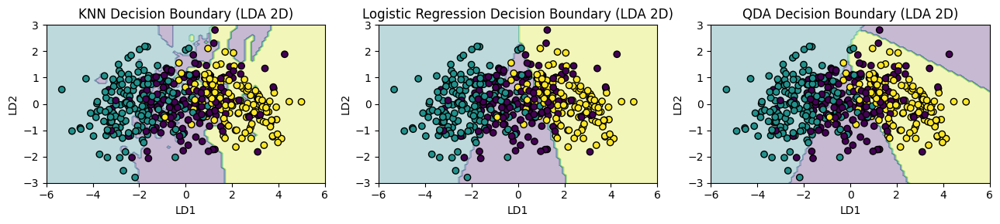

In [13]:
plt.figure(figsize=(13,3))


ax1 = plt.subplot(1,3, 1)
DecisionBoundaryDisplay.from_estimator(
    knn_classifier,
    X_test_projected_ht,
    response_method="predict",
    alpha=0.3,
    ax=ax1
)

ax1.scatter(
    X_test_projected_ht[:, 0],
    X_test_projected_ht[:, 1],
    c=y_test_ht,
    edgecolor='k'
)

ax1.set_xlim(-6, 6)
ax1.set_ylim(-3, 3)
ax1.set_title("KNN Decision Boundary (LDA 2D)")
ax1.set_xlabel("LD1")
ax1.set_ylabel("LD2")


ax2 = plt.subplot(1, 3, 2)

DecisionBoundaryDisplay.from_estimator(
    linear_classifier,
    X_test_projected_ht,
    response_method="predict",
    alpha=0.3,
    ax=ax2
)

ax2.scatter(
    X_test_projected_ht[:, 0],
    X_test_projected_ht[:, 1],
    c=y_test_ht,
    edgecolor='k'
)

ax2.set_xlim(-6, 6)
ax2.set_ylim(-3, 3)
ax2.set_title("Logistic Regression Decision Boundary (LDA 2D)")
ax2.set_xlabel("LD1")
ax2.set_ylabel("LD2")


ax3 = plt.subplot(1, 3, 3)
qda_2d = QuadraticDiscriminantAnalysis()
qda_2d.fit(x_train_projected_ht, y_train_ht)


DecisionBoundaryDisplay.from_estimator(
    qda_2d,
    X_test_projected_ht,
    response_method="predict",
    alpha=0.3,
    ax=ax3
)

ax3.scatter(
    X_test_projected_ht[:, 0],
    X_test_projected_ht[:, 1],
    c=y_test_ht,
    edgecolor='k'
)
ax3.set_xlim(-6, 6)
ax3.set_ylim(-3, 3)
ax3.set_title("QDA Decision Boundary (LDA 2D)")
ax3.set_xlabel("LD1")
ax3.set_ylabel("LD2")

plt.tight_layout()
plt.show()

# Q2 [4]
## Goal: 
implement K-Means and Gaussian Mixture Model (GMM / EM) from scratch, apply them to the provided image, 
pick an optimal number of clustersk (and state/justify the criterion you used), reconstruct the image using the cluster assignments, and compare the results for multiple initialization methods.


You may use any library functions to compute PSNR and SSIM, as well as for reading and plotting images. The use of NumPy is also permitted.


Task 1. Implement K-Means and GMM from scratch

In [ ]:
# kmeans implementation

def get_random_centroids(X, n_clusters):
    '''
    Select n_clusters random samples from X as initial centroids.
    Every sample has equal probability of being chosen as a centroid.
    '''
    n_samples = X.shape[0]
    return X[np.random.choice(n_samples, n_clusters, replace=False)].copy()

def get_kmeans_plus_plus_centroids(X, n_clusters):
    '''
    return centriods such that they are far from each other.
    Every sample has diiferent probabilty, based on its distance from already chosen centroids.
    '''
    n_samples = X.shape[0]
    centroids = []
    idx = np.random.choice(n_samples)
    centroids.append(X[idx])

    for _ in range(1, n_clusters):
        # distance of each sample from already chosen centroids
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2) 

        # distance to nearest centroid
        closest_distances = np.min(distances, axis=1) 

        # calc probabilities for each sample
        select_prob = closest_distances ** 2 / np.sum(closest_distances ** 2) 

        # choose one sample as centroid based on probabilities
        next_idx = np.random.choice(n_samples, p=select_prob) 
        centroids.append(X[next_idx])

    return np.array(centroids)

def kmeans(X, n_clusters, max_iters=100,tolerance=1e-4,random_state=None, initialization='random'):

    '''
    X: training data
    n_clusters: number of clusters
    max_iters: maximum iterations to run
    tolerance: threshold for convergence
    random_state: seed for reproducibility
    initialization: method for initializing centroids

    returns: final centroids, label for each sample, number of iterations run
    '''
    if random_state is not None:
        np.random.seed(random_state)
    n_samples, n_features = X.shape

    # any sample is a possible centroid
    if initialization == 'random': 
        centroids = get_random_centroids(X, n_clusters)

    # samples are chosen depending on their distance from existing centroids
    elif initialization == 'kmeans++': 
        centroids = get_kmeans_plus_plus_centroids(X, n_clusters)
    else:
        raise ValueError("Invalid initialization method. Choose 'random' or 'kmeans++'.")

    
    for iters in range(max_iters):
        # distance of each sample from each centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2) 
        
        # nearest centroid for each sample
        closest_centroids = np.argmin(distances, axis=1) 
        
        #update centroids as mean of assigned samples
        new_centroids = np.array([X[closest_centroids == k].mean(axis=0) for k in range(n_clusters)]) 
        
        # break if centroids do not change significantly
        # if np.all(np.abs(centroids - new_centroids) < tolerance): 
        if np.linalg.norm(centroids - new_centroids) < tolerance:
            break
        
        centroids = new_centroids
    
    return centroids, closest_centroids, iters

# GMM implementation
def GaussianPDF(X, mean, cov):

    '''
    X: data points (n_samples, n_features)
    mean: mean vector of the Gaussian (n_features,)
    cov: covariance matrix (n_features, n_features)

    returns: probability density function values for each sample
    '''
    n_features = X.shape[1]
    diff = X - mean
    inv_cov = np.linalg.inv(cov)
    # (x-mean)T@inv_cov@(x-mean) 
    exponent = np.einsum('ij,jk,ik->i', diff, inv_cov, diff) 
    # (1/(2*pi)^(d/2)*|cov|^(1/2))*exp(-0.5*(x-mean)T@inv_cov@(x-mean))
    pdf = np.exp(-0.5 * exponent) / np.sqrt((2 * np.pi) ** n_features * np.linalg.det(cov)) 
    return pdf

def GMM(X, n_components, max_iters=100, tolerance=1e-4, random_state=None, initialization='random'):

    '''
    X: training data
    n_components: number of components
    max_iters: maximum iterations to run
    tolerance: threshold for convergence
    random_state: seed for reproducibility
    initialization: method for initializing means

    returns: final means, covariances, weights, number of iterations run, log likelihood
    '''
    if random_state is not None:
        np.random.seed(random_state)

    n_samples, n_features = X.shape

    if initialization == 'random':
        means = get_random_centroids(X, n_components)

    elif initialization == 'kmeans++':
        means = get_kmeans_plus_plus_centroids(X, n_components)
    else:
        raise ValueError("Invalid initialization method. Choose 'random' or 'kmeans++'.")

    log_likelihood = -np.inf

    # initialize covariances as covariance whole data
    # each component can have different covariance.
    I_dash = np.eye(n_features)*epsilon # small value for stability
    covariances = np.array([np.cov(X, rowvar=False) + I_dash for _ in range(n_components)])  
    
    # weight of each cluster
    weights = np.ones(n_components) / n_components 

    for iters in range(max_iters):
        
        # E-step: calculate responsibilities

        # prob of each sample belonging to each component
        pdf = np.zeros((n_samples, n_components))
        for k in range(n_components):
            Gaussian = GaussianPDF(X, means[k], covariances[k]) 
            pdf[:, k] = weights[k] * Gaussian

        # normalize along classes to get probabilities
        responsibilities = pdf / (pdf.sum(axis=1, keepdims=True) + epsilon) # adding small value to avoid division by zero

        # M-step: update parameters
        
        # number of samples assigned to each component (can be a fraction)
        Nk = responsibilities.sum(axis=0) 
        
        # mean of each cluster - weighted avg of each sample
        means = (responsibilities.T @ X) / Nk[:, np.newaxis] 

        for k in range(n_components):
            diff = X - means[k]
            # wk*∑(xi−mk​)(xi−mk​)T/ Nk 
            covariances[k] = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff / Nk[k] + I_dash # adding small value for stability
            
        # new weights - fraction of sample in each cluster 
        weights = Nk / n_samples

        
        for k in range(n_components):
            pdf[:, k] = weights[k] * GaussianPDF(X, means[k], covariances[k])

        # break if means do not change significantly
        updated_log_likelihood = np.sum(np.log(pdf.sum(axis=1) + epsilon)) 
        if np.linalg.norm(updated_log_likelihood - log_likelihood) < tolerance:
            break

        log_likelihood = updated_log_likelihood

    return means, covariances, weights, iters, log_likelihood

Task 2. Fit K-Means and GMM to the given image and determine the optimal number of clusters (k). Clearly specify the criterion used to select (k) (e.g., elbow method, silhouette score, or ..). Justify the selected value. Using this optimal (k), reconstruct the image with both K-Means and GMM and plot the original and reconstructed images.


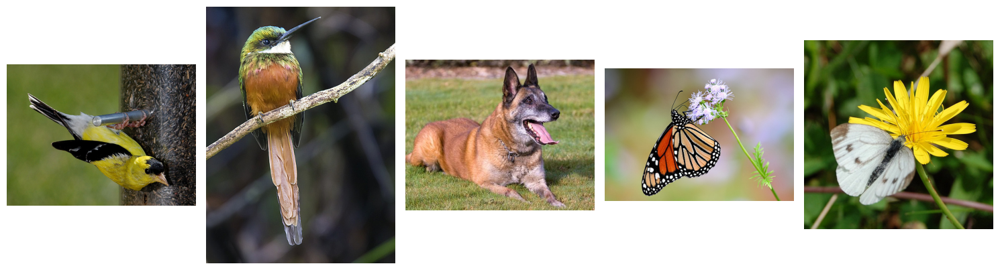

In [15]:
# visualizing given images
image_filepaths = ["img1.JPEG", "img2.JPEG", "img3.JPEG","img4.JPEG", "img5.JPEG"]
images = [plt.imread(file) for file in image_filepaths]
plt.figure(figsize=(3*len(images), 10))
for idx,image in enumerate(images):
    plt.subplot(1, len(images), idx+1)
    plt.imshow(image)
    plt.axis('off')
plt.tight_layout()
plt.show()

0it [00:00, ?it/s]

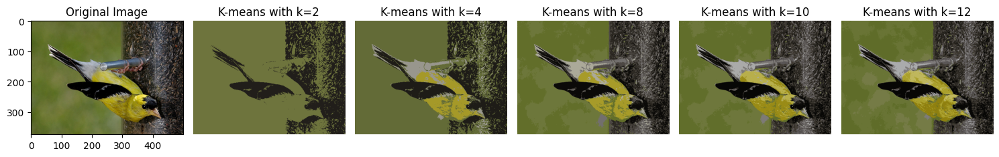

Optimal k for image 1: 8


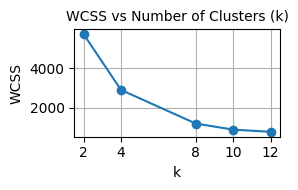

1it [00:25, 25.32s/it]

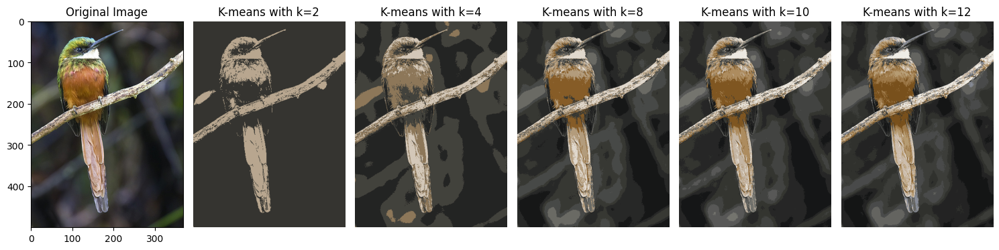

Optimal k for image 2: 4


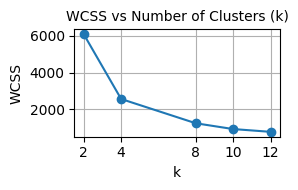

2it [00:55, 27.98s/it]

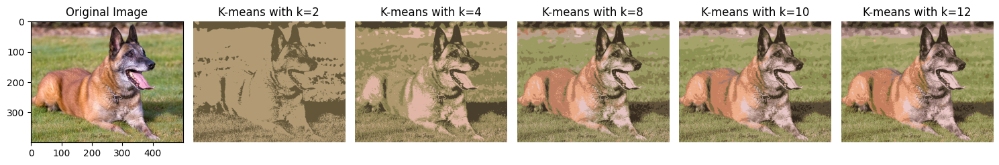

Optimal k for image 3: 4


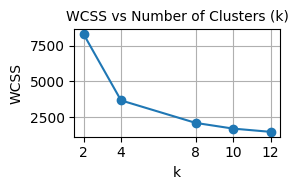

3it [01:30, 31.11s/it]

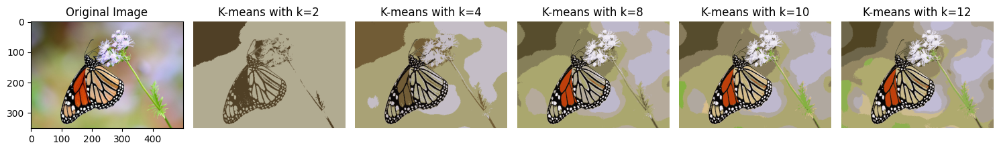

Optimal k for image 4: 4


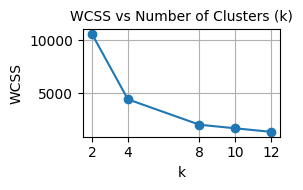

4it [02:15, 36.96s/it]

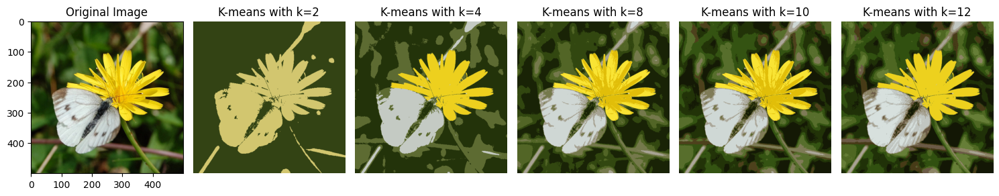

Optimal k for image 5: 4


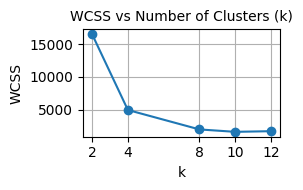

5it [03:09, 37.90s/it]


In [ ]:
# kmeans for image segmentation

def compute_wcss(X, labels, centroids):
    '''
    X: data points (n_samples, n_features)
    labels: cluster assignment for each sample (n_samples,)
    centroids: cluster centroids (n_clusters, n_features)

    returns: within-cluster sum of squares (WCSS) i.e. sum of squared distances of samples to their closest cluster center
    '''
    wcss = 0.0
    for j in range(centroids.shape[0]):
        cluster_points = X[labels == j]
        if cluster_points.size > 0:
            wcss += np.sum((cluster_points - centroids[j]) ** 2)
    return wcss

def find_elbow(wcss, k_values):
    '''
    wcss: list of WCSS values for different k
    k_values: corresponding k values
    returns: optimal k (second derivative method)
    '''
    wcss = np.array(wcss,dtype=float)
    if len(wcss)<=2:
        return k_values[0]
    
    second_diff = np.diff(np.diff(wcss))
    elbow = np.argmax(second_diff)+1
    return k_values[elbow]

'''
for all images perform kmeans with different k values and plot the segmented images and wcss graph.
find the optimal k for each image using the elbow method and print it.
'''
k_values = [2, 4, 8, 10, 12] 
k_opt_list = [] 
wcss_values = {}

for idx,img in tqdm(enumerate(images)):
    h, w, c = img.shape
    # n_samples, n_features = h*w, c
    img_reshaped = img.reshape(-1, c)/255.0
    wcss_values[idx] = []

    plt.figure(figsize=(15, 4*len(k_values)))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(img)
    plt.title('Original Image')

    plot_idx = 2
    for k in k_values:
        centroids, labels, iters = kmeans(img_reshaped.copy(), n_clusters=k)
        segmented_img = centroids[labels].reshape(h, w, c) 
        wcss = compute_wcss(img_reshaped, labels, centroids) 
        wcss_values[idx].append(wcss)

        plt.subplot(1, len(k_values)+1, plot_idx)
        plt.imshow(segmented_img)
        plt.title(f'K-means with k={k}')
        plt.axis('off')
        plot_idx += 1

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.plot(k_values, wcss_values[idx], marker='o')
    plt.title('WCSS vs Number of Clusters (k)',fontsize=10)
    plt.xlabel('k')
    plt.ylabel('WCSS')
    plt.xticks(k_values)
    plt.grid()

    k_opt_img = find_elbow(wcss_values[idx], k_values)
    k_opt_list.append(k_opt_img)
    print(f"Optimal k for image {idx+1}: {k_opt_img}")

    plt.tight_layout()
    plt.show()

Most frequently optimal k across images: 4


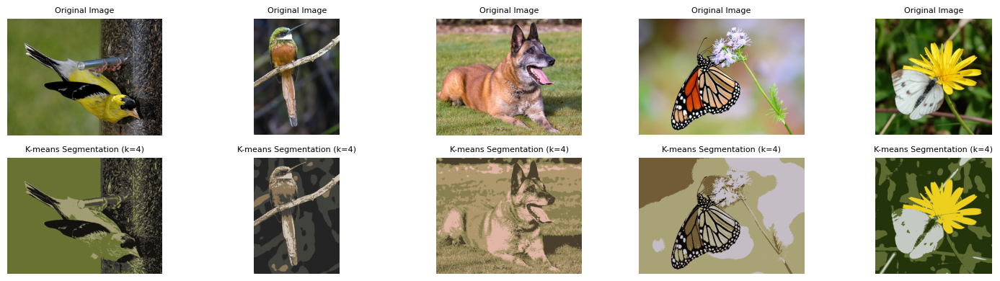

In [ ]:
'''
get number with max frequency in k_opt_list
plot segmented images for that k for all images and compare with original images.
'''
k_opt_kmeans = Counter(sorted(k_opt_list)).most_common(1)[0][0] 
print(f"Most frequently optimal k across images: {k_opt_kmeans}")
plt.figure(figsize=(3*len(images),4))
for idx,img in enumerate(images):
    h, w, c = img.shape
    img_reshaped = img.reshape(-1, c)/255.0
    centroids_opt, labels_opt, iters_opt = kmeans(img_reshaped, n_clusters=k_opt_kmeans)
    segmented_img_opt = centroids_opt[labels_opt].reshape(h, w, c)

    plt.subplot(2,len(images), idx+1) 
    plt.imshow(img)
    plt.title('Original Image',fontsize=8)
    plt.axis('off')

    plt.subplot(2,len(images), idx+1+len(images))
    plt.imshow(segmented_img_opt)
    plt.title(f'K-means Segmentation (k={k_opt_kmeans})',fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

100%|██████████| 4/4 [06:32<00:00, 98.03s/it] 


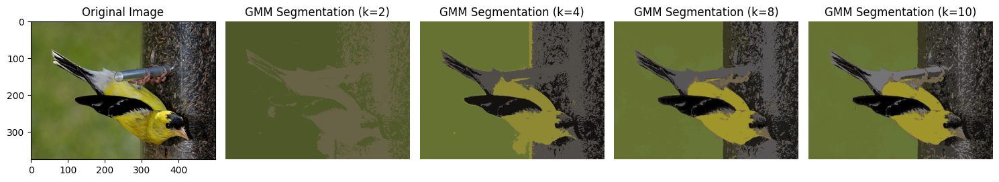

Optimal k for image 1 based on AIC: 4, based on BIC: 4


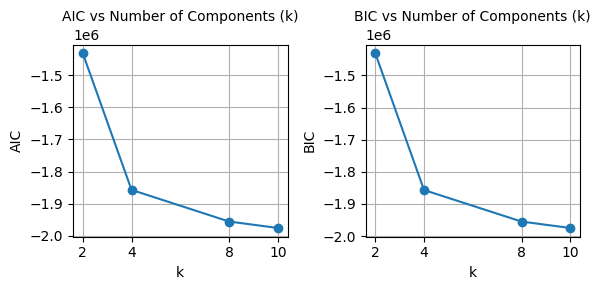

100%|██████████| 4/4 [05:56<00:00, 89.21s/it] 


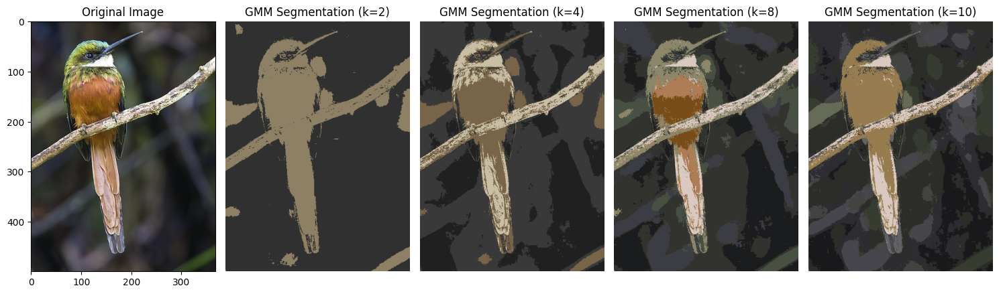

Optimal k for image 2 based on AIC: 8, based on BIC: 8


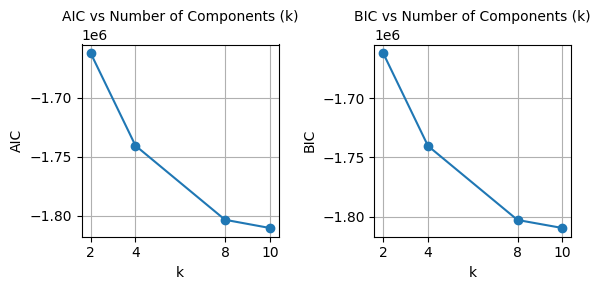

100%|██████████| 4/4 [05:52<00:00, 88.16s/it] 


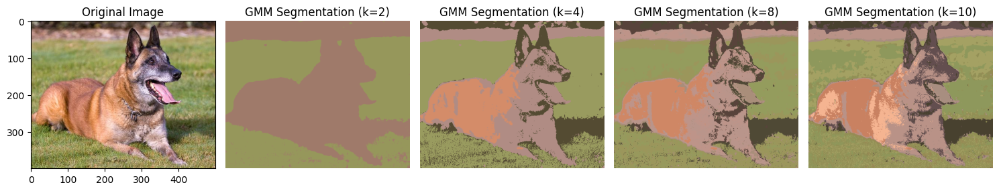

Optimal k for image 3 based on AIC: 8, based on BIC: 8


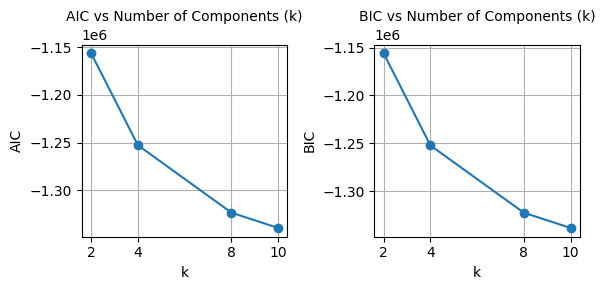

100%|██████████| 4/4 [06:30<00:00, 97.70s/it] 


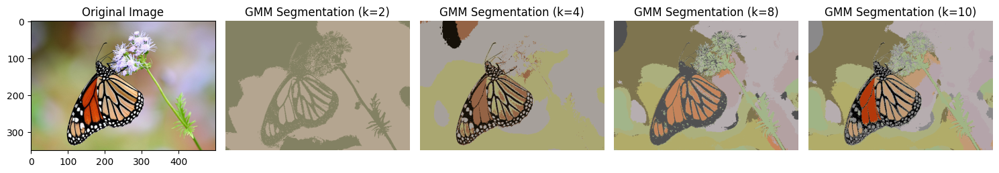

Optimal k for image 4 based on AIC: 4, based on BIC: 4


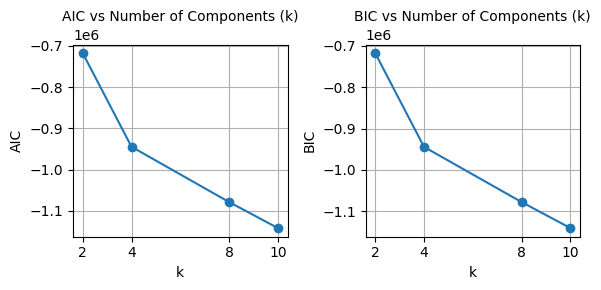

100%|██████████| 4/4 [08:26<00:00, 126.59s/it]


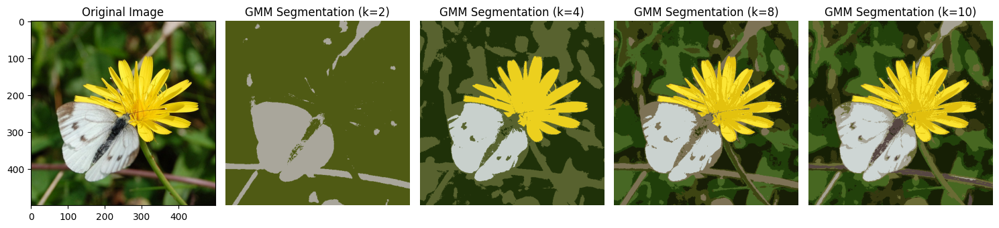

Optimal k for image 5 based on AIC: 4, based on BIC: 4


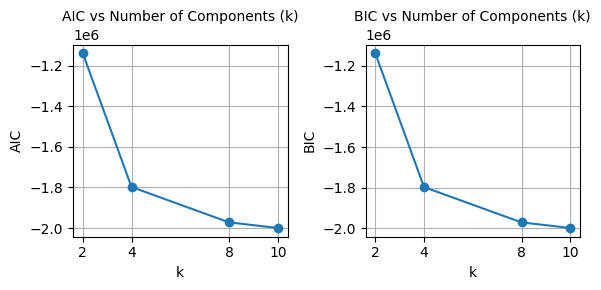

In [ ]:
'''
GMM for image segmentation
for all images perform GMM with different k values and plot the segmented images and AIC/BIC graph.
use aic and bic to find optimal k for each image and print it.
'''

k_values_gmm = [2, 4, 8, 10]

k_opt_aic = []
k_opt_bic = []

for idx,img in enumerate(images):
    h, w, c = img.shape
    img_reshaped = img.reshape(-1, c)/255.0

    aic_values = []
    bic_values = []

    plt.figure(figsize=(15, 4*len(k_values_gmm)))
    plt.subplot(1, len(k_values_gmm)+1, 1)
    plt.imshow(img)
    plt.title('Original Image')

    plot_idx = 2

    for k in tqdm(k_values_gmm):
        means, covariances, weights, iters, log_likelihood = GMM(img_reshaped, n_components=k)
        segmented_img_gmm = np.zeros_like(img_reshaped)

        for i in range(img_reshaped.shape[0]):
            probs = np.array([weights[j] * GaussianPDF(img_reshaped[i:i+1], means[j], covariances[j]) for j in range(k)])
            segmented_img_gmm[i] = means[np.argmax(probs)]

        segmented_img_gmm = segmented_img_gmm.reshape(h, w, c)
        plt.subplot(1, len(k_values_gmm)+1, plot_idx)
        plt.imshow(segmented_img_gmm)
        plt.title(f'GMM Segmentation (k={k})')
        plt.axis('off')
        plot_idx += 1

        # Calculate AIC and BIC
        log_likelihood = np.sum(np.log(np.sum([weights[j] * GaussianPDF(img_reshaped, means[j], covariances[j]) for j in range(k)], axis=0) + epsilon))
        n_params = k * (c + c*(c+1)/2) + (k - 1)  # mean + covariance + weights
        aic = 2 * n_params - 2 * log_likelihood
        bic = n_params * np.log(img_reshaped.shape[0]) - 2 * log_likelihood

        aic_values.append(aic)
        bic_values.append(bic)

    # k_opt_aic.append(k_values_gmm[np.argmin(aic_values)])
    # k_opt_bic.append(k_values_gmm[np.argmin(bic_values)])
    k_opt_aic.append(find_elbow(aic_values, k_values_gmm))
    k_opt_bic.append(find_elbow(bic_values, k_values_gmm))

    plt.tight_layout()
    plt.show()

    print(f"Optimal k for image {idx+1} based on AIC: {k_opt_aic[-1]}, based on BIC: {k_opt_bic[-1]}")

    # width,length for plot 
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.plot(k_values_gmm, aic_values, marker='o')
    plt.title('AIC vs Number of Components (k)',fontsize=10)
    plt.xlabel('k')
    plt.ylabel('AIC')
    plt.xticks(k_values_gmm)
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(k_values_gmm, bic_values, marker='o')
    plt.title('BIC vs Number of Components (k)',fontsize=10)
    plt.xlabel('k')
    plt.ylabel('BIC')
    plt.xticks(k_values_gmm)
    plt.grid()


    plt.tight_layout()
    plt.show()

Most frequently optimal k for GMM across images: 4


5it [02:34, 30.92s/it]


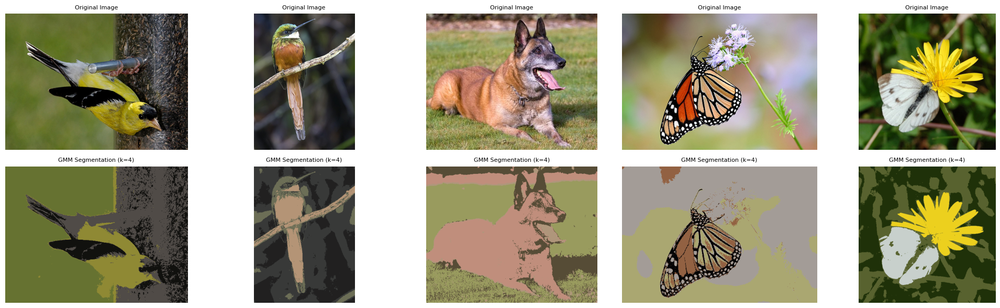

In [19]:
# for gmm segmentation with optimal k
k_opt_gmm = min(Counter(k_opt_aic).most_common(1)[0][0],Counter(k_opt_bic).most_common(1)[0][0])
print(f"Most frequently optimal k for GMM across images: {k_opt_gmm}")
plt.figure(figsize=(4*len(images), 6))
for idx,img in tqdm(enumerate(images)):
    h, w, c = img.shape
    img_reshaped = img.reshape(-1, c)/255.0
    means_opt, covariances_opt, weights_opt, iters_opt, log_likelihood_opt = GMM(img_reshaped, n_components=k_opt_gmm)
    
    # assign each pixel to the component with highest responsibility
    responsibilities_opt = np.zeros((img_reshaped.shape[0], k_opt_gmm))
    I_dash = np.eye(c)*epsilon # small value for stability
    for k in range(k_opt_gmm):
        responsibilities_opt[:, k] = weights_opt[k] * GaussianPDF(img_reshaped, means_opt[k], covariances_opt[k]+I_dash)  
    labels_gmm = np.argmax(responsibilities_opt, axis=1)
    
    segmented_img_gmm = means_opt[labels_gmm].reshape(h, w, c)

    plt.subplot(2, len(images), idx+1)
    plt.imshow(img)
    plt.title('Original Image',fontsize=8)
    plt.axis('off')

    plt.subplot(2, len(images), idx+1+len(images))
    plt.imshow(segmented_img_gmm)
    plt.title(f'GMM Segmentation (k={k_opt_gmm})',fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

Task 3. With the optimal (k) from part 2, run K-Means and GMM using at least two different initialization. For each initialization and algorithm, record the iterations-to-converge, reconstruct the image, and compute PSNR and SSIM versus the original. Present the reconstructed images, and summarize differences in convergence speed and image quality across initializations.


0it [00:00, ?it/s]

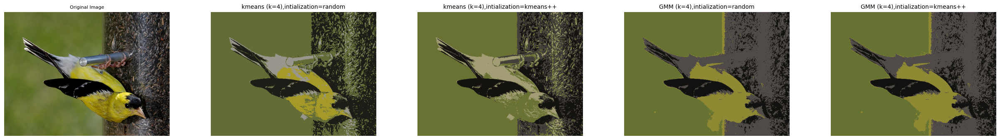

1it [00:59, 59.33s/it]

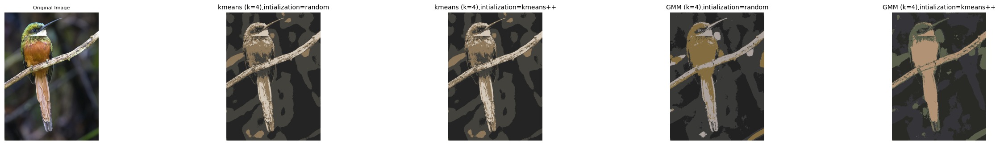

2it [02:12, 67.32s/it]

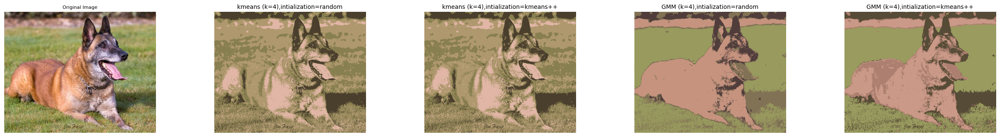

3it [03:29, 71.78s/it]

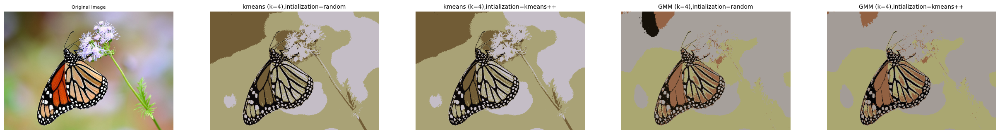

4it [04:32, 68.22s/it]

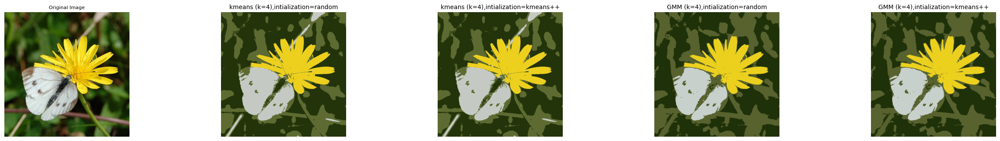

5it [05:29, 65.96s/it]


In [ ]:
'''
kmeans and GMM with different initialization methods
for each image, perform kmeans and GMM with optimal k and both random and kmeans++ initialization.
plot the segmented images and calculate PSNR and SSIM for each method and initialization.'''
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

results = []

for idx,img in tqdm(enumerate(images)):

    h, w, c = img.shape
    img_reshaped = img.reshape(-1, c)/255.0

    plt.figure(figsize=(5*len(images), 16))
    plt.subplot(len(images), 5, 5*idx+1)
    plt.imshow(img)
    plt.title('Original Image',fontsize=8)
    plt.axis('off')

    for j,method in enumerate(['kmeans', 'GMM']):

        for i,init in enumerate(['random','kmeans++']):
            if method == 'kmeans':
                k_opt = k_opt_kmeans
                centroids_opt, labels_opt,iter_opt = kmeans(img_reshaped, n_clusters=k_opt, initialization=init)
                segmented_img_opt = centroids_opt[labels_opt].reshape(h, w, c)

            elif method == 'GMM':
                k_opt = k_opt_gmm
                means_opt, covariances_opt, weights_opt, iters_opt, log_likelihood_opt = GMM(img_reshaped, n_components=k_opt, initialization=init)
                responsibilities_opt = np.zeros((img_reshaped.shape[0], k_opt))
                I_dash = np.eye(c)*epsilon 

                for k in range(k_opt):
                    responsibilities_opt[:, k] = weights_opt[k] * GaussianPDF(img_reshaped, means_opt[k], covariances_opt[k]+I_dash)  
                labels_gmm = np.argmax(responsibilities_opt, axis=1)
                segmented_img_opt = means_opt[labels_gmm].reshape(h, w, c)

            psnr_value = psnr(img/255.0, segmented_img_opt,data_range=1.0)
            ssim_value = ssim(img/255.0, segmented_img_opt, channel_axis=-1, data_range=1.0)

            # print(f"PSNR for {method}: {psnr_value:.4f}, SSIM for {method}: {ssim_value:.4f} for {init} initialization with {iters_opt} iterations")
            results.append([idx+1,method, init, iters_opt, psnr_value, ssim_value])

            plt.subplot(len(images), 5, 5*idx+j*2+i+2)
            plt.imshow(segmented_img_opt)
            plt.title(f'{method} (k={k_opt}),intialization={init}',fontsize=10)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
'''
tabulate results for the above experiment.
can be run multiple times to see the effect of random initialization on results.
'''
print(tabulate(results, headers=['Image', 'Method', 'Initialization', 'Iterations', 'PSNR', 'SSIM'], tablefmt='grid'))

+---------+----------+------------------+--------------+---------+----------+
|   Image | Method   | Initialization   |   Iterations |    PSNR |     SSIM |
+=========+==========+==================+==============+=========+==========+
|       1 | kmeans   | random           |           81 | 22.8673 | 0.77224  |
+---------+----------+------------------+--------------+---------+----------+
|       1 | kmeans   | kmeans++         |           81 | 23.1448 | 0.802186 |
+---------+----------+------------------+--------------+---------+----------+
|       1 | GMM      | random           |           99 | 19.882  | 0.630493 |
+---------+----------+------------------+--------------+---------+----------+
|       1 | GMM      | kmeans++         |           99 | 19.8787 | 0.630257 |
+---------+----------+------------------+--------------+---------+----------+
|       2 | kmeans   | random           |           99 | 23.3253 | 0.779658 |
+---------+----------+------------------+--------------+--------

# Q3 [7 marks]

### **Dataset:**
Breast Cancer Wisconsin Dataset (CSV file is given in the folder)

---

### **Tasks:**

#### **1. Implement from scratch (NumPy only):**
- `LogisticRegression` class
- `SMO_SVM` class with kernels: Linear, Polynomial, RBF
  - Reference: https://cs229.stanford.edu/materials/smo.pdf

  **Dual form of the soft-margin SVM:**

  $$
  \max_{\alpha} \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j K(x_i, x_j)
  $$

  subject to:

  $$
  0 \leq \alpha_i \leq C, \quad \forall i \qquad \text{and} \qquad \sum_{i=1}^{N} \alpha_i y_i = 0
  $$

  where $ \alpha_i $ are Lagrange multipliers, $ y_i \in \{-1, 1\} $ are class labels, $ K(x_i, x_j) $ is the kernel function, and $ C $ is the regularization parameter.

#### **2. Train and compare:**
- Train on full-dimensional data (30D) and on PCA-reduced data at various dimensions (e.g., 2D, 5D, 10D, etc.)
- For every reduced dimension used, report the **dimension reduction** (e.g., 30D → 5D) and the **percentage reduction** (e.g., 83.3%)
- Split: 70:15:15 (train:val:test), report performance metrics on test split
- Show how performance changes as the number of PCA dimensions varies
- Compare metrics across models and settings, write observations


---

### **Library Constraints:**

| Allowed | Not Allowed |
|---------|-------------|
| NumPy, Pandas (data loading), Matplotlib (plotting), sklearn PCA | sklearn for Logistic Regression or SVM |

---

### **Deliverables:**

**Code:**
- `LogisticRegression` class
- `SMO_SVM` class with Linear, Polynomial, and RBF kernels

**Metrics:**
- Performance metrics on test split (70:15:15)
- For each PCA dimension used, report: original → reduced dimension and % reduction
- Performance vs. dimensionality plot (accuracy across different PCA dimensions)
- Comparison across models/settings with observations


#### **3. Visualize decision boundaries in 2D:** [optional and extra 2 marks]
- Plot decision boundaries for all models and kernels for **both** cases:
  - Models trained on PCA-reduced data
  - Models trained on full 30D data
- Highlight support vectors
**Visualizations:**
- Decision boundaries for all models/kernels trained on PCA-reduced data
- Decision boundaries for all models/kernels trained on full 30D data

**Written Analysis:**
- Which kernel produces the best decision boundary? Justify.
- Effect of dimensionality reduction on performance and boundary shape.
- Geometric differences between kernel boundaries.
- Explain your approach for visualizing 30D decision boundaries in 2D.

---


### **Optional Question Bonus Instructions:**

The optional question (worth 2 marks) provides additional points that accumulate across all assignments. 

**How Optional Marks Work:**
- Optional marks accumulate across both assignments (each worth 15 marks, total 30 marks)
- Applied as bonus points to your total assignment score
- Final assignment component score is capped at 30 marks maximum
- Optional marks compensate for lost points in regular questions across assignments
- Provides a buffer to maintain high performance in the assignment component


In [22]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [ ]:
class LogisticRegression:
    '''
    input parameters:
    learning_rate: step size for gradient descent
    threshold: decision boundary for classification
    max_iters: maximum number of iterations for training
    reg_lambda: regularization strength for L2 regularization
    '''
    def __init__(self, learning_rate=0.01, threshold=0.5, max_iters=1000,reg_lambda=0.01):
        self.learning_rate = learning_rate 
        self.max_iters = max_iters 
        self.weights = None
        self.bias = None
        self.threshold = threshold
        self.reg_lambda = reg_lambda  

    def sigmoid(self, z):
        # to prevent overflow in exp, clip it to a reasonable range
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        '''
        X: training data (n_samples, n_features)
        y: binary labels (n_samples,)
        fits to data using gradient descent with L2 regularization i.e learns weights and bias
        '''
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.max_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            dreg = self.reg_lambda * self.weights  / n_samples
            dw += dreg  

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        '''
        gives class labels (0 or 1) for each sample in X based on the threshold
        '''
        y_predicted = self.predict_probability(X)
        return np.where(y_predicted >= self.threshold, 1, 0)

    def predict_probability(self, X):
        '''
        gives probability of belonging to class 1 for each sample in X
        '''
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

In [24]:
'''
decision boundary :- wx-b=0
margins :- wx-b=1 and wx-b=-1
point on margin :- support vectors
correct classification :- y(wx-b) > 1 (because margin is 1 unit away from decision boundary)

hinge loss :- max(0,1-y(wx-b)) for every point
regularization term :- C*||w||^2
total loss :- regularization term + hinge loss
gradient :- dw = dJi/dwk = 2C*wk-yi*xik | 2C*wk
         :- db = dJi/db = -yi | 0 

w = w-lr*dw
b = b-lr*db

for SMO (Sequential Minimal Optimization)
optimization function :- W(α) = ∑αi - 0.5*∑∑αi*αj*yi*yj*K(xi,xj)
maximize W(α) with respect to αi and αj
given :- 0 ≤ αi ≤ C, ∑αiyi = 0
decision function :- f(x) = ∑αiyiK(xi,x) + b
'''
# different kernels 
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x, y, degree=3, coef0=1):
    return (np.dot(x, y) + coef0) ** degree

def rbf_kernel(x, y, gamma):
    diff = x - y
    return np.exp(-gamma * np.dot(diff, diff))

In [ ]:
class SMO_SVM:
    '''
    input parameters:
    kernel: type of kernel to use ('linear', 'polynomial', 'rbf')
    C: regularization parameter
    tol: tolerance for stopping criterion
    max_iter: maximum number of iterations for training
    gamma: kernel coefficient for rbf kernel
    degree: degree for polynomial kernel
    coef0: independent term in polynomial kernel

    '''
    def __init__(self, kernel='linear', C=1.0, tol=1e-3, max_iter=100, gamma=None, degree=None, coef0=None):
        self.kernel = kernel
        self.C = C  # regularization parameter
        self.tol = tol # tolerance for stopping criterion
        self.max_iter = max_iter
        self.alphas = None
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.b = 0 # bias 
        self.X = None # support vectors
        self.y = None # support vector labels

    def _K(self, x1, x2):
        '''
        decides kernel function
        '''
        if self.kernel == 'linear':
            return linear_kernel(x1, x2)
        elif self.kernel == 'polynomial':
            return polynomial_kernel(x1, x2, degree=self.degree, coef0=self.coef0)
        elif self.kernel == 'rbf':
            if self.gamma is None:
                self.gamma = 1.0 / x1.shape[1]  # Default gamma
            return rbf_kernel(x1, x2, gamma=self.gamma)
        else:
            raise ValueError("Unsupported kernel")

    def compute_LH(self, alpha_i, alpha_j, y_i, y_j):
        '''
        bounds for alpha
        '''
        if y_i != y_j:
            '''
            if samples belong to different classes, then the bounds are:
            L = max(0, alpha_j - alpha_i)
            H = min(C, C + alpha_j - alpha_i)
            '''
            L = max(0, alpha_j - alpha_i)
            H = min(self.C, self.C + alpha_j - alpha_i)
        else:
            '''
            if samples belong to the same class, then the bounds are:
            L = max(0, alpha_i + alpha_j - C)
            H = min(C, alpha_i + alpha_j)
            '''
            L = max(0, alpha_i + alpha_j - self.C)
            H = min(self.C, alpha_i + alpha_j)
        return L, H

    def get_random_index(self, i, n_samples):
        '''
        for i,j pair
        '''
        j = i
        while j == i:
            j = np.random.randint(0, n_samples)
        return j

    def calculate_bias(self, E_i, E_j, alpha_i_old, alpha_j_old, i, j):
        '''
        bi = old_bias 
            - Ei 
            - yi*(alpha_i_new - alpha_i_old)*K(xi,xi) 
            - yj*(alpha_j_new - alpha_j_old)*K(xi,xj)

        bj = old_bias 
            - Ej
            - yi*(alpha_i_new - alpha_i_old)*K(xi,xj)
            - yj*(alpha_j_new - alpha_j_old)*K(xj,xj)
        '''
        bi = self.b \
            - E_i \
            - self.y[i] * (self.alphas[i] - alpha_i_old) * self.K[i, i] \
            - self.y[j] * (self.alphas[j] - alpha_j_old) * self.K[i, j]
        bj = self.b \
            - E_j \
            - self.y[i] * (self.alphas[i] - alpha_i_old) * self.K[i, j] \
            - self.y[j] * (self.alphas[j] - alpha_j_old) * self.K[j, j]

        if 0 < self.alphas[i] < self.C:
            return bi
        elif 0 < self.alphas[j] < self.C:
            return bj
        else:
            return (bi + bj) / 2

    def kkt_violated(self, f_i, y_i, alpha_i):
        '''
        KKT conditions for SVM:
        1. If alpha_i = 0, then y_i * f(x_i) >= 1 (correctly classified and outside margin)
        2. If 0 < alpha_i < C, then y_i * f(x_i) = 1 (on the margin)
        3. If alpha_i = C, then y_i * f(x_i) <= 1 (misclassified or inside margin)
        '''
        # if (alpha_i == 0 and y_i * E_i >= 1) or (0 < alpha_i < self.C and abs(y_i * E_i - 1) < self.tol) or (alpha_i == self.C and y_i * E_i <= 1):
        #     return False
        # return True

        y_f = y_i * f_i

        # Case 1: alpha_i = 0
        if alpha_i < self.tol:
            return y_f < 1 - self.tol

        # Case 2: 0 < alpha_i < C
        elif alpha_i > self.tol and alpha_i < self.C - self.tol:
            return abs(y_f - 1) > self.tol

        # Case 3: alpha_i = C
        else:
            return y_f < 1 - self.tol
    

    def fit(self, X, y):
        '''
        X: training data (n_samples, n_features)
        y: binary labels (n_samples,)

        fits the model using Sequential Minimal Optimization (SMO) algorithm
        i.e. learns the alphas and bias for a given kernel function
        '''
        n_samples, n_features = X.shape
        self.X = X
        self.y = y
        self.b = 0
        self.alphas = np.zeros(n_samples) # ∑αiyi = 0

        # PRECOMPUTE KERNEL MATRIX
        self.K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                self.K[i, j] = self._K(X[i], X[j])

        passes = 0
        while passes < self.max_iter:
            num_changed_alphas = 0 
            for i in range(n_samples):
                f_i = np.sum(self.alphas * self.y * self.K[:, i]) + self.b
                E_i = f_i - y[i] # error for point i 
                
                if self.kkt_violated(f_i, y[i], self.alphas[i]):
                    j = self.get_random_index(i, n_samples)
                    f_j =  np.sum(self.alphas * self.y * self.K[:, j]) + self.b
                    E_j = f_j - y[j] # error for point j

                    # save for comparison
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]

                    # constraints αiyi + αjyj = 0 and 0 ≤ αi, αj ≤ C
                    L, H = self.compute_LH(alpha_i_old, alpha_j_old, y[i], y[j])

                    if L == H:
                        # skip update
                        continue
                    
                    # η = d2W/dαj2 = 2K(xi,xj) - K(xi,xi) - K(xj,xj)
                    eta = 2 * self.K[i,j] - self.K[i, i] - self.K[j, j]
                    if eta >= 0:
                        # skip update
                        continue

                    # updated alpha should be in calculated bounds
                    self.alphas[j] -= y[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    if abs(self.alphas[j] - alpha_j_old) < self.tol:
                        continue
                    
                    # constraints αiyi + αjyj = 0 => αi_new = αi_old + yi*yj*(αj_old - αj_new)
                    self.alphas[i] += y[i] * y[j] * (alpha_j_old - self.alphas[j])

                    # bias
                    self.b = self.calculate_bias(E_i, E_j, alpha_i_old, alpha_j_old, i, j)

                    num_changed_alphas += 1

            if num_changed_alphas == 0:
                passes += 1
            else:
                passes = 0

    def _project(self, x):
        '''
        decision function f(x) = ∑αiyiK(xi,x) + b
        this gives the distance of point x from the decision boundary
        '''
        prediction = 0
        for i in range(len(self.alphas)):
            if self.alphas[i] > 0:
                prediction += self.alphas[i] * self.y[i] * self._K(self.X[i], x)
        return prediction + self.b

    # def predict(self, X):
    #     return np.array([np.sign(self._project(x)) for x in X])

    def predict(self, X):
        '''
        positive means one class and negative means other class
        the sign of this value determines the predicted class label for x
        '''
        return np.array([1 if self._project(x) >= 0 else -1 for x in X ])

        

In [26]:
data = pd.read_csv('breast_cancer_detection_data.csv')
print('Columns in the dataset:',data.columns.tolist())
print('Null values in column',data.isnull().sum()[data.isnull().sum()!=0])
data.head()

Columns in the dataset: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
Null values in column Unnamed: 32    569
dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [27]:
data.drop(columns=['Unnamed: 32'], inplace=True) # drop the column with all nan values
labels = data['diagnosis']
features = data.drop(columns=['id', 'diagnosis']).values
data.drop(columns=['id', 'diagnosis'], inplace=False).describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
'''
standardize the features acc to Z-score essential for PCA and better gradient descent convergence
'''
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [ ]:
X = features_scaled
y_bin = (labels == "M").astype(int) # malignant = 1, benign = 0
y_svm = np.where(y_bin == 1, 1, -1) # malignant = 1, benign = -1 for SVM

X_train_full, X_temp, y_train_bin, y_temp_bin, y_train_svm, y_temp_svm = train_test_split(
    X, y_bin, y_svm, test_size=0.3, random_state=0, stratify=y_bin
)

X_val_full, X_test_full, y_val_bin, y_test_bin, y_val_svm, y_test_svm = train_test_split(
    X_temp, y_temp_bin, y_temp_svm, test_size=0.5, random_state=0, stratify=y_temp_bin
)

print("Train size:", X_train_full.shape[0])
print("Val size:", X_val_full.shape[0])
print("Test size:", X_test_full.shape[0])


Train size: 398
Val size: 85
Test size: 86


In [30]:
def apply_pca(X_train, X_val, X_test, n_components,random_state=0):
    pca = PCA(n_components=n_components, random_state=random_state)
    X_train_p = pca.fit_transform(X_train)
    X_val_p = pca.transform(X_val)
    X_test_p = pca.transform(X_test)
    variance_retained = np.sum(pca.explained_variance_ratio_) * 100 
    return X_train_p, X_val_p, X_test_p, variance_retained

In [ ]:
# For different PCA dimensions

pca_dims = [2, 5, 10, 15, 30]  # 30 = full
models = [LogisticRegression, SMO_SVM]
SVM_parameters = {
    'linear': {'kernel': 'linear', 'C': 1.0, 'max_iter': 10},
    'polynomial': {'kernel': 'polynomial', 'C': 1.0, 'degree': 3, 'coef0': 1, 'max_iter': 10},
    'rbf': {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1, 'max_iter': 10}
}

def result_matrix(model,model_params,X_train,y_train_true,X_test,y_test_true):#
    model_instance = model(**model_params)
    model_instance.fit(X_train, y_train_true)
    y_pred = model_instance.predict(X_test)
    acc = accuracy_score(y_test_true, y_pred)
    prf = precision_recall_fscore_support(y_test_true, y_pred, average="binary", zero_division=0)
    return acc, prf


results_logreg = []
results_svm = {'linear':[],'polynomial':[],'rbf':[]}

for d in tqdm(pca_dims):
    if d < X_train_full.shape[1]:
        X_train_p, X_val_p, X_test_p,vr = apply_pca(
            X_train_full, X_val_full, X_test_full, n_components=d
        )
    else:
        # use original features
        X_train_p, X_val_p, X_test_p = X_train_full, X_val_full, X_test_full
        vr = 100

    
    for model in models:
        if model == LogisticRegression:
            params = {'learning_rate': 0.01, 'max_iters': 200, 'reg_lambda': 1e-4}
            acc_lr, prf_lr = result_matrix(model,params ,X_train_p,y_train_bin, X_test_p, y_test_bin)
            results_logreg.append((d, 'Logistic Regression',vr, acc_lr, *prf_lr))

        elif model == SMO_SVM:
            for kernel_name, params in SVM_parameters.items():
                acc_svm, prf_svm = result_matrix(model, params,X_train_p,y_train_svm, X_test_p, y_test_svm)
                results_svm[kernel_name].append((d, kernel_name ,vr, acc_svm, *prf_svm))
 



  0%|          | 0/5 [00:00<?, ?it/s]

{'learning_rate': 0.01, 'max_iters': 200, 'reg_lambda': 0.0001}
{'kernel': 'linear', 'C': 1.0, 'max_iter': 10}
{'kernel': 'polynomial', 'C': 1.0, 'degree': 3, 'coef0': 1, 'max_iter': 10}
{'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1, 'max_iter': 10}


 20%|██        | 1/5 [00:32<02:09, 32.49s/it]

{'learning_rate': 0.01, 'max_iters': 200, 'reg_lambda': 0.0001}
{'kernel': 'linear', 'C': 1.0, 'max_iter': 10}
{'kernel': 'polynomial', 'C': 1.0, 'degree': 3, 'coef0': 1, 'max_iter': 10}
{'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1, 'max_iter': 10}


 40%|████      | 2/5 [00:46<01:05, 21.79s/it]

...

 60%|██████    | 3/5 [00:53<00:30, 15.01s/it]

{'learning_rate': 0.01, 'max_iters': 200, 'reg_lambda': 0.0001}
{'kernel': 'linear', 'C': 1.0, 'max_iter': 10}
{'kernel': 'polynomial', 'C': 1.0, 'degree': 3, 'coef0': 1, 'max_iter': 10}
{'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1, 'max_iter': 10}


 80%|████████  | 4/5 [01:03<00:12, 12.96s/it]

{'learning_rate': 0.01, 'max_iters': 200, 'reg_lambda': 0.0001}
{'kernel': 'linear', 'C': 1.0, 'max_iter': 10}
{'kernel': 'polynomial', 'C': 1.0, 'degree': 3, 'coef0': 1, 'max_iter': 10}
{'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1, 'max_iter': 10}


100%|██████████| 5/5 [01:15<00:00, 15.19s/it]


In [32]:
# make all list to one
res = results_logreg + results_svm['linear'] + results_svm['polynomial'] + results_svm['rbf']
res[0]

(2,
 'Logistic Regression',
 np.float64(63.25612006829322),
 0.9186046511627907,
 0.8787878787878788,
 0.90625,
 0.8923076923076924,
 None)

In [38]:
# tabulate results for all
print(tabulate(res,
 headers=['PCA Dim', 'Model','Variance Retained (%)', 'Accuracy', 'Precision', 'Recall', 'F1-Score',''],
  tablefmt='grid'))

+-----------+---------------------+-------------------------+------------+-------------+----------+------------+----+
|   PCA Dim | Model               |   Variance Retained (%) |   Accuracy |   Precision |   Recall |   F1-Score |    |
+===========+=====================+=========================+============+=============+==========+============+====+
|         2 | Logistic Regression |                 63.2561 |   0.918605 |    0.878788 |  0.90625 |   0.892308 |    |
+-----------+---------------------+-------------------------+------------+-------------+----------+------------+----+
|         5 | Logistic Regression |                 85.1043 |   0.930233 |    0.882353 |  0.9375  |   0.909091 |    |
+-----------+---------------------+-------------------------+------------+-------------+----------+------------+----+
|        10 | Logistic Regression |                 95.5019 |   0.930233 |    0.882353 |  0.9375  |   0.909091 |    |
+-----------+---------------------+---------------------

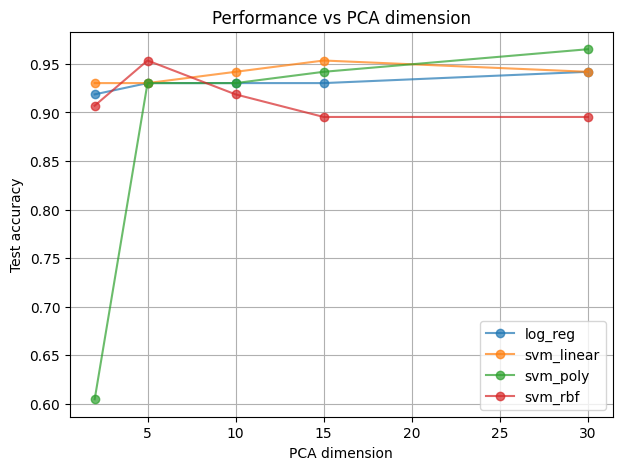

In [ ]:
# accuracy vs PCA dimension plot 

def extract_acc(results):
    '''
    for plotting 
    '''
    dims = [r[0] for r in results]
    accs = [r[3] for r in results]
    return dims, accs

plt.figure(figsize=(7, 5))

for model,result_ in [('log_reg',results_logreg),('svm_linear', results_svm['linear']),('svm_poly', results_svm['polynomial']),('svm_rbf', results_svm['rbf'])]:
    dims, accs = extract_acc(result_)
    plt.plot(dims, accs, marker="o", label=model,alpha=0.7)  # using model name from first entry

plt.xlabel("PCA dimension")
plt.ylabel("Test accuracy")
plt.title("Performance vs PCA dimension")
plt.legend()
plt.grid(True)
plt.show()


Training Logistic Regression on 2D data...
Training SVM (Linear) on 2D data...
Training SVM (Polynomial) on 2D data...
Training SVM (RBF) on 2D data...


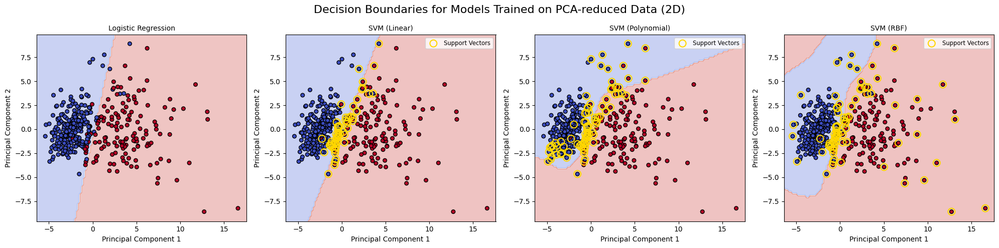

Training Logistic Regression on 30D data...
Training SVM (Linear) on 30D data...
Training SVM (Polynomial) on 30D data...
Training SVM (RBF) on 30D data...


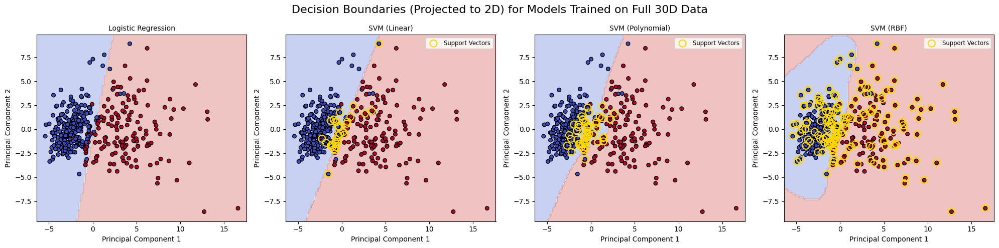

In [ ]:
'''
Optional Question: Decision Boundary Visualization
PS: do not consider it for grading, write up is also not there for in report for this part
Experimented a bit for visualzation and model accuracy and "Man ki shanti"
'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_decision_boundary(ax, model, X_2d, y, title, is_svm=False, pca_model=None, is_30d=False):
    # Create a 2D meshgrid based on the PCA-reduced data limits
    step_size = 0.2 
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                         np.arange(y_min, y_max, step_size))
    
    #Flatten grid to pass into the model for prediction
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    
    if is_30d:
        # Map the 2D grid points back to the 30D space using inverse PCA
        grid_input = pca_model.inverse_transform(grid_2d)
    else:
        # Use 2D grid directly if model was trained on 2D data
        grid_input = grid_2d
        
    # Predict on the grid
    Z = model.predict(grid_input)
    Z = Z.reshape(xx.shape)
    
    # Plot decision contour and scatter the actual 2D points
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=30)
    
    # Highlight Support Vectors (only applicable for SVM models)
    if is_svm and hasattr(model, 'alphas'):
        # In SMO, alphas > 0 indicate support vectors (using 1e-4 for float precision)
        sv_indices = np.where(model.alphas > 1e-4)[0]
        if len(sv_indices) > 0:
            sv_points = model.X[sv_indices]
            
            # If the model was trained on 30D, we must project SVs back to 2D for visualization
            if is_30d:
                sv_points_2d = pca_model.transform(sv_points)
            else:
                sv_points_2d = sv_points
                
            ax.scatter(sv_points_2d[:, 0], sv_points_2d[:, 1], s=100,
                       linewidth=1.5, facecolors='none', edgecolors='gold', label='Support Vectors')
            ax.legend(loc='upper right', fontsize='small')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')



# Fit PCA to reduce the 30D data to 2D
pca_2d = PCA(n_components=2, random_state=0)
X_train_2d = pca_2d.fit_transform(X_train_full)

# Dictionary of model configurations 
model_configs = [
    ('Logistic Regression', LogisticRegression {'learning_rate': 0.01, 'max_iters': 200, 'reg_lambda': 1e-4}, False),
    ('SVM (Linear)', SMO_SVM, {'kernel': 'linear', 'C': 1.0, 'max_iter': 10}, True),
    ('SVM (Polynomial)', SMO_SVM, {'kernel': 'polynomial', 'C': 1.0, 'degree': 3, 'coef0': 1, 'max_iter': 10}, True),
    ('SVM (RBF)', SMO_SVM, {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1, 'max_iter': 10}, True)
]

fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
fig1.suptitle('Decision Boundaries for Models Trained on PCA-reduced Data (2D)', fontsize=16)

for ax, (name, ModelClass, params, is_svm) in zip(axes1, model_configs):
    model_2d = ModelClass(**params)
    y_target = y_train_svm if is_svm else y_train_bin
    
    print(f"Training {name} on 2D data...")
    model_2d.fit(X_train_2d, y_target)
    plot_decision_boundary(ax, model_2d, X_train_2d, y_target, name, is_svm=is_svm, is_30d=False)

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
fig2.suptitle('Decision Boundaries (Projected to 2D) for Models Trained on Full 30D Data', fontsize=16)

for ax, (name, ModelClass, params, is_svm) in zip(axes2, model_configs):
    model_30d = ModelClass(**params)
    y_target = y_train_svm if is_svm else y_train_bin
    
    print(f"Training {name} on 30D data...")
    model_30d.fit(X_train_full, y_target)
    plot_decision_boundary(ax, model_30d, X_train_2d, y_target, name, is_svm=is_svm, pca_model=pca_2d, is_30d=True)

plt.tight_layout()
plt.show()
